### Diffusion diff car controll model  
Epoch [20/20] - Loss: 0.016906  
Step 5000 (Epoch 5) - Current Batch Loss: 0.011580  

In [1]:
import os
# torchをインポートする前に設定
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [2]:
import os
import sys
from pathlib import Path

#export PYTHONPATH=$PYTHONPATH:/home/nishi/local/git-download/lerobot/src
# パスを通す（お使いの環境に合わせて絶対パスに書き換えてください）
# git clone をした、パスを使ってください。
lerobot_path = "/home/nishi/local/git-download/lerobot"
sys.path.append(os.path.join(lerobot_path, "src"))

import torch
import torch.nn as nn
import torchvision.models as models
#from diffusers.models.unets.unet_1d import UNet1DModel

from diffusers.schedulers.scheduling_ddim import DDIMScheduler

# 学習時のハイパーパラメータ
BATCH_SIZE = 32          # 8GBに収めるため32（エラーなら16）に設定
#NUM_EPOCHS = 50
#NUM_EPOCHS = 2
#NUM_EPOCHS = 8
NUM_EPOCHS = 14

IMAGE_SIZE = (224, 224)  # 画像は224x224にリサイズしてVRAMを節約



In [3]:
#%%writefile DiffCarPolicy.py
import torch
import torch.nn as nn
import torchvision.models as models
#from diffusers.models.unets.unet_1d import UNet1DModel

#from diffusers.schedulers.scheduling_ddim import DDIMScheduler
# 公式リポジトリなどからConditionalUnet1Dのクラスをインポート（または自作）
#from diffusers.models.embeddings import TimestepEmbedding

# ─── 拡散モデル用の最小限の1D-UNetブロック ───
class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, cond_dim):
        super().__init__()
        self.blocks = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_channels),
            nn.Mish(),
            nn.Conv1d(out_channels, out_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_channels)
        )
        # 条件ベクトル（時間＋画像＋ゴール）を各ブロックに染み込ませるための層
        self.cond_mlp = nn.Sequential(
            nn.Mish(),
            nn.Linear(cond_dim, out_channels)
        )
        self.residual_conv = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
        self.final_act = nn.Mish()

    def forward(self, x, cond):
        out = self.blocks[0](x)
        # 条件を時間軸方向に拡張して足し算
        c = self.cond_mlp(cond).unsqueeze(-1)
        out = self.final_act(self.blocks[1:](out + c) + self.residual_conv(x))
        return out

# ─── メインのポリシーネットワーク ───
class DiffCarPolicy(nn.Module):
    def __init__(self, obs_horizon=2, pred_horizon=16):
        super().__init__()
        self.obs_horizon = obs_horizon
        self.pred_horizon = pred_horizon
        
        # 1. 画像特徴量抽出用 (ResNet-18) -> 512次元
        self.vision_encoder = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.vision_encoder.fc = nn.Identity() 
        
        # 2. 目的地座標 [dx, dy] の処理用 -> 64次元
        self.goal_encoder = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64)
        )
        
        # 画像(512) + ゴール(64) = 576次元 * 2フレーム = 1152次元
        self.cond_dim = (512 + 64) * obs_horizon
        
        # タイムステップ（時間情報）を埋め込む層 -> 128次元
        self.time_encoder = nn.Sequential(
            nn.Linear(1, 128),
            nn.Mish(),
            nn.Linear(128, 128)
        )
        
        # 統合された条件の総次元数: 1152 + 128 = 1280次元
        total_cond_dim = self.cond_dim + 128
        
        # 3. 完全自作のクリーンな1D-UNet構造
        # 外部の勝手な仕様変更に一切左右されません！
        self.down1 = ResidualBlock1D(2, 128, total_cond_dim)
        self.down2 = ResidualBlock1D(128, 256, total_cond_dim)
        self.mid = ResidualBlock1D(256, 512, total_cond_dim)
        self.up1 = ResidualBlock1D(512 + 256, 128, total_cond_dim)
        self.up2 = ResidualBlock1D(128 + 128, 64, total_cond_dim)
        
        self.final_layer = nn.Conv1d(64, 2, kernel_size=1) # 最終的に [v, ω] の2次元へ
        
    def forward(self, noisy_actions, timesteps, image, goal_vector):
        # noisy_actions の形状: [B, 2, 16]
        B, _, T = noisy_actions.shape
        O = self.obs_horizon
        
        # 1. 画像とゴールから特徴量を抽出 [B, 1152]
        C, H, W = image.shape[2:]
        img_features = self.vision_encoder(image.view(B*O, C, H, W)).view(B, O, 512) 
        goal_features = self.goal_encoder(goal_vector.view(B*O, 2)).view(B, O, 64) 
        cond_flat = torch.cat([img_features, goal_features], dim=-1).view(B, -1) 
        
        # 2. 時間情報を埋め込み [B, 128]
        # timestepsを [B, 1] のFloat型に変形して入力
        time_features = self.time_encoder(timesteps.unsqueeze(-1).float())
        
        # 3. すべての条件（画像＋ゴール＋時間）を一本に統合 [B, 1280]
        global_cond = torch.cat([cond_flat, time_features], dim=-1)
        
        # 4. UNetのフォワード処理（スキップ接続付き）
        d1 = self.down1(noisy_actions, global_cond) # [B, 128, 16]
        d2 = self.down2(d1, global_cond)           # [B, 256, 16]
        
        m = self.mid(d2, global_cond)               # [B, 512, 16]
        
        u1 = self.up1(torch.cat([m, d2], dim=1), global_cond)  # [B, 128, 16]
        u2 = self.up2(torch.cat([u1, d1], dim=1), global_cond) # [B, 64, 16]
        
        # 5. 予測されたノイズを 2チャンネル [v, ω] で出力
        noise_pred = self.final_layer(u2) # [B, 2, 16]
        
        return noise_pred



In [4]:
#%%writefile ResizeWithPadTensor.py
import torch
import torch.nn.functional as F
class ResizeWithPadTensor:
    def __init__(self, size=(224,224)):
        self.target_h = size[0]
        self.target_w = size[1]
    def __call__(self, img):
        # --------------------------------
        # img:
        # [B,C,H,W]
        # --------------------------------
        B, C, H, W = img.shape
        # --------------------------------
        # scale
        # --------------------------------
        scale = min(
            self.target_w / W,
            self.target_h / H
        )
        new_w = int(W * scale)
        new_h = int(H * scale)
        # --------------------------------
        # resize
        # --------------------------------
        img = F.interpolate(
            img,
            size=(new_h, new_w),
            mode="bilinear",
            align_corners=False
        )
        # --------------------------------
        # padding size
        # --------------------------------
        pad_left = (self.target_w - new_w) // 2
        pad_right = self.target_w - new_w - pad_left
        pad_top = (self.target_h - new_h) // 2
        pad_bottom = self.target_h - new_h - pad_top
        # --------------------------------
        # pad
        # F.pad order:
        # (left,right,top,bottom)
        # --------------------------------
        img = F.pad(
            img,
            (
                pad_left,
                pad_right,
                pad_top,
                pad_bottom
            ),
            value=0
        )
        return img

#### LeRobot Datsets を使って、data set を作成します。  


In [5]:
import os
import torch
from torch.utils.data import Dataset
from lerobot.datasets.lerobot_dataset import LeRobotDataset

class DiffCarDataset(Dataset):
    def __init__(self, dataset_dir, obs_horizon=2, pred_horizon=16):
        self.obs_horizon = obs_horizon
        self.pred_horizon = pred_horizon
        
        # 🌟 あなたが気づいた「最高の機能」をここに適用します！
        # 15Hz（1秒に15フレーム）を想定し、未来16ステップ分のアクションを1発で取る設定
        # 過去2フレーム分の画像も同様にdelta_timestampsで一発で取得します
        delta_cfg = {
            # 過去の画像とステート： [t-1, t] を取得
            "observation.images": [i / 15.0 for i in range(-obs_horizon + 1, 1)],
            "observation.state": [i / 15.0 for i in range(-obs_horizon + 1, 1)],
            # 未来のアクション： [t, t+1, ... t+15] を一括取得
            "action": [i / 15.0 for i in range(pred_horizon)]
        }
        
        # LeRobotDatasetを、delta_timestamps付きでロード
        #self.lerobot_dataset = LeRobotDataset(root_dir=dataset_dir, delta_timestamps=delta_cfg)
        self.lerobot_dataset = LeRobotDataset("motion",root=dataset_dir, delta_timestamps=delta_cfg)
        
        self.resize=ResizeWithPadTensor()

        # 有効なフレームインデックスの計算
        self.indices = []
        for ep_idx in range(self.lerobot_dataset.num_episodes):
            ep_meta = self.lerobot_dataset.meta.episodes[ep_idx]
            #start_frame = ep_meta['start_frame']
            # このエピソードが全体の中のどこから始まるかを計算 (1回400フレーム)
            start_frame = int(self.lerobot_dataset.meta.episodes["dataset_from_index"][ep_idx])

            #end_frame = ep_meta['end_frame']
            end_frame = int(self.lerobot_dataset.meta.episodes["dataset_to_index"][ep_idx])

            num_frames = end_frame - start_frame
            
            # 過去バッファと未来予測の余白が綺麗に取れるインデックスだけを抽出
            start_min = obs_horizon - 1
            start_max = num_frames - pred_horizon
            
            for t in range(start_min, start_max + 1):
                self.indices.append(start_frame + t)
                
        print(f"🚀 [真・LeRobotインジェクター] 初期化完了！総サンプル数: {len(self.indices)} (メモリ消費量: 0 MB)")

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # 基準となるフレーム(t)の絶対インデックスを取得
        t = self.indices[idx]
        
        # 🌟 🌟 🌟 ここが劇的にシンプル＆爆速になります 🌟 🌟 🌟
        # delta_timestampsを設定しているため、dataset[t] を1回叩くだけで、
        # 過去2枚の画像、過去2個のゴール、未来16個のアクションが、
        # 内部で「未来の画像をデコードする無駄な処理」を1ミリも挟まずに、完璧な形状で返ってきます！
        frame_data = self.lerobot_dataset[t]
        
        # 1. 過去2フレームの画像 [2, 3, H:224, W:224]
        image_tensor = frame_data["observation.images"].float()
        
        # 2. 過去2フレームのゴールベクトル [2, 2] （20m割りのノーマライズ！）
        goal_tensor = frame_data["observation.state"].float() / 20.0
        
        # 3. 未来16ステップのアクション [16, 2]
        action_tensor = frame_data["action"].float()
        
        # 🌟 あなたのリサイズクラスの適用（必要に応じて有効化）
        image_tensor = self.resize(image_tensor)
        # ImageNet標準の平均と標準偏差で画像をノーマライズ
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        image_tensor = (image_tensor - mean) / std
        
        return {
            'image': image_tensor,
            'goal': goal_tensor,
            'action': action_tensor
        }

In [6]:

# train.py 内での記述例
from torch.utils.data import DataLoader
#from dataset import DiffCarDataset

#data_set_path="./outputs/tugbot_nav2_imitation_2_tf"
data_set_path="outputs/tugbot_nav2_imitation_3_tf_diff"

# 1. データセットの初期化
dataset = DiffCarDataset(
    dataset_dir=data_set_path, 
    obs_horizon=2,       # 過去2フレーム（現在含む）を入力
    pred_horizon=16      # 未来16ステップ（約1.6秒先まで）を予測
)

# 2. DataLoader の作成（GTX 1070用にバッチサイズを 32 に設定）
train_loader = DataLoader(
    dataset, 
    batch_size=BATCH_SIZE,       # VRAM 8GBに収めるための最適値。これでも重ければ 16 に下げる
    shuffle=True,        # データをシャッフルして学習を安定させる
    #num_workers=2,        # データ読み込みの並列スレッド数
    num_workers=0,
    pin_memory=True      # GPUへのデータ転送を高速化
)

# 3. 学習ループ内での取り出しテスト
for batch in train_loader:
    # データをGPUに転送
    images = batch['image'].to('cuda') # [32, 2, 3, 224, 224]
    goals = batch['goal'].to('cuda')   # [32, 2, 2]
    actions = batch['action'].to('cuda') # [32, 16, 2]
    
    print("バッチのデータ形状:")
    print("画像の形状:", images.shape)
    print("ゴールの形状:", goals.shape)
    print("アクション（速度）の形状:", actions.shape)
    
    break # テストのため1ループで抜ける

🚀 [真・LeRobotインジェクター] 初期化完了！総サンプル数: 33578 (メモリ消費量: 0 MB)
バッチのデータ形状:
画像の形状: torch.Size([32, 2, 3, 224, 224])
ゴールの形状: torch.Size([32, 2, 2])
アクション（速度）の形状: torch.Size([32, 16, 2])


type(img): <class 'torch.Tensor'>
img.shape: torch.Size([224, 224, 3])
img.min(): tensor(0.)  img.max(): tensor(1.)


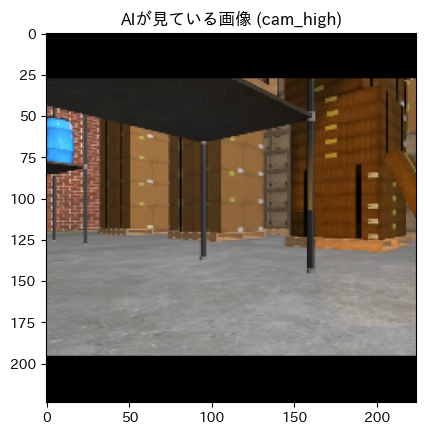

In [7]:
import matplotlib.pyplot as plt
import japanize_matplotlib # これを足すだけで日本語が使えるようになります
import torch

for batch in train_loader:
    # データをGPUに転送
    bt = batch['image'].to('cpu') # [32, 2, 3, 224, 224]
    img_tensor = bt[0, 0] # [3, 224, 224] のノーマライズ済みテンソル

    # 🌟 追加: 表示のために逆標準化 (stdを掛けて、meanを足す)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_unnorm = (img_tensor * std) + mean # 0.0 〜 1.0 の範囲に戻る
    
    # Matplotlib用に [224, 224, 3] に転置
    img = img_unnorm.permute(1, 2, 0)
    
    print('type(img):',type(img))
    # model inputs は、(3,480,640) で、色順は、RGB です。
    # plt.imshow()は、デフォルトでRGB（赤・緑・青）の順序 なので、 model の入力も RGB のままです。
    # 2. 画像を表示してみる (PyTorchの [C, H, W] 形式を pillow.show 用の [H, W, C] に変換)
    #img = frame["observation.images.top"].permute(1, 2, 0)
    print('img.shape:',img.shape)  # img.shape: torch.Size([480, 640, 3]) これは、あくまで、pillow 用です。
    print('img.min():',img.min(),' img.max():',img.max())
    plt.imshow(img)
    plt.title("AIが見ている画像 (cam_high)")
    plt.show()
    break # テストのため1ループで抜ける


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用デバイス: {device}")

# データセットとローダーの準備
#dataset = DiffCarDataset(dataset_dir=data_set_path, obs_horizon=2, pred_horizon=16)
#train_loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)

# モデルと最適化アルゴリズムの初期化
policy = DiffCarPolicy(obs_horizon=2, pred_horizon=16).to(device)
optimizer = torch.optim.AdamW(policy.parameters(), lr=1e-4, weight_decay=1e-6)

# 拡散モデルのノイズスケジューラー（DDIMを採用）
noise_scheduler = DDIMScheduler(
    num_train_timesteps=100,
    beta_schedule='squaredcos_cap_v2',
    clip_sample=True,
    prediction_type='epsilon' # ノイズそのものを予測する設定
)

out_dir="./output/train_diff"

# ログ保存用フォルダ
#os.makedirs("./checkpoints", exist_ok=True)
os.makedirs(out_dir, exist_ok=True)

print("トレーニングを開始します...")
num_epochs = NUM_EPOCHS # サンプル数が1220件なので、まずは50〜100エポック程度で様子見
global_step = 0 # 🌟 追加: 通算のステップ（バッチ処理）数カウンター

for epoch in range(num_epochs):
    policy.train()
    epoch_loss = 0.0
    
    for batch in train_loader:
        # データをGPUへ
        n_image = batch['image'].to(device)
        torch.cuda.empty_cache()

        n_goal = batch['goal'].to(device)
        gt_action = batch['action'].to(device) # 人間のお手本アクション [B, 16, 2]
        
        B = gt_action.shape[0]
        
        # ① お手本アクションに混ぜる「純粋なノイズ」を生成
        noise = torch.randn_like(gt_action)
        
        # ② 各バッチに対してランダムなタイムステップ（0〜99）を選択
        timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps, (B,), device=device).long()
        
        # ③ お手本アクションにノイズをスケジュール通りに混ぜる (順方向拡散)
        # 1D-UNetの仕様 [B, チャンネル, 時間軸] に合わせるため転置
        gt_action_t = gt_action.transpose(1, 2) # [B, 2, 16]
        noise_t = noise.transpose(1, 2)         # [B, 2, 16]
        
        noisy_actions = noise_scheduler.add_noise(gt_action_t, noise_t, timesteps)
        
        # ④ モデル（AI）に「このノイズまみれのアクションから、混ぜられたノイズを当ててみろ」と要求
        pred_noise_t = policy(noisy_actions, timesteps, n_image, n_goal)
        
        # ⑤ 実際のノイズと、AIが予測したノイズの間の誤差（MSE Loss）を計算
        loss = nn.functional.mse_loss(pred_noise_t, noise_t)
        
        # ⑥ 逆伝播とウェイト更新
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        global_step += 1 # 🌟 追加: 1バッチ処理するたびに加算

        # 🌟 🌟 🌟 【大改造】指定ステップ（例: 200ステップ）ごとに画面にLossを表示する 🌟 🌟 🌟
        if global_step % 200 == 0:
            print(f"Step {global_step} (Epoch {epoch+1}) - Current Batch Loss: {loss.item():.6f}")

    # エポック終了時の平均ロス表示
    print(f"Epoch [{epoch+1}/{num_epochs}] Finished - Average Loss: {epoch_loss / len(train_loader):.6f}")
    
    # 10エポックごとにモデルを保存
    #if (epoch + 1) % 10 == 0:
    if (epoch + 1) % 4 == 0:
        save_path=os.path.join(out_dir, f"checkpoint_{epoch+1}.pth")
        torch.save(policy.state_dict(), save_path)
        latest_save_path=os.path.join(out_dir, f"checkpoint_latest.pth")
        torch.save(policy.state_dict(), latest_save_path)
        print(f"➔ モデルを保存しました: {save_path}")
        

In [ ]:
latest_path = os.path.join(out_dir, "latest_model.pth")
# --- 5. 最後にモデルを保存 (Final Model) ---
torch.save(policy.state_dict(), latest_path)
print(f"最終モデルを保存しました: {latest_path}")
